In [1]:
from pathlib import Path
import pygimli as pg  # Stelle sicher, dass das Modul pg importiert ist und verfügbar ist
from pygimli.physics import ert
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime
import os
import numpy as np

from Hilfsfunktionen import T_corr_nach_Inversion
from Hilfsfunktionen import plotting_function
from Hilfsfunktionen import plotting_function_FTL

# Read data
file = "two_timesteps_240710_240808.ohm"
two_timesteps = True
base_dir = Path("filtered_data")
data = []
for unterordner in base_dir.iterdir():
    if unterordner.is_dir():
        datei_pfad = unterordner / "two_timesteps_240710_240808.ohm" 
        if datei_pfad.exists():
            daten_objekt = pg.load(str(datei_pfad))
            data.append([unterordner.name, daten_objekt])
            print(f"Load data: {datei_pfad}")

# Create method manager
manager = []
for ts in data:
    manager.append(ert.ERTManager(ts[1], verbose=True))

# Create mesh
mesh = manager[0].createMesh(quality = 34, paraMaxCellSize=0.5, paraDepth=15)
manager[0].invert(quality = 34, paraMaxCellSize=0.5, maxIter=1 ,dPhi= 0.1, paraDepth=15,lam=20)

# Inversion without temperature correction
DATA = [dat[1] for dat in data]
# Full time-lapse
scalef = 0.8
fop = pg.frameworks.MultiFrameModelling(ert.ERTModelling, scalef=scalef)
fop.setData(DATA)
#manager[0].createMesh(quality=34,paraMaxCellSize=20)
fop.setMesh(mesh)
print(fop.mesh())  # important to call mesh() function once!
dataVec = np.concatenate([data["rhoa"] for data in DATA])
errorVec = np.concatenate([data["err"] for data in DATA])
startModel = fop.createStartModel(dataVec)
inv = pg.Inversion(fop=fop, startModel=startModel, verbose=True)
model = inv.run(dataVec, errorVec, maxIter=10, lam= 12, startModel=startModel, verbose=True,stopAtChi1=False)
chi2_oT = []
chi2_oT.append(round(inv.chi2(),2))
mod = np.reshape(model, [len(DATA), -1])

# PLot
#plotting_function_FTL(data,manager = manager, results = mod, folder_name= 'FTL', filename= 'Two_timesteps_without_Tcorr', chi2=chi2_oT, scalef=scalef, rrms=rrms)

# Temperature correction    
ort_2 = 'Georg-Westermann-Park'
mod_corr = []
temp_spread = []
timestep = 0
mesh2 = manager[0].mesh.createSubMesh(manager[0].mesh.cells(manager[0].mesh.cellMarkers() == 2))
for count, m in enumerate(mod):
    if two_timesteps:
        add = 10
    else:
        add = 0
    timestep = count+add
    dateien = os.listdir(r".\Temperature_data/" + ort_2 )
    for datei in dateien: 
        if (datei).startswith('T_Profil%s_array' % (str(timestep))):
            print(datei)
            Temp_tiefe_vektor = np.load(r'.\Temperature_data/%s/' % (ort_2) + datei, allow_pickle=True)
    res_new,Tem_new = T_corr_nach_Inversion(m, mesh2, Temp_tiefe_vektor)
    mod_corr.append(res_new)
    temp_spread.append(Tem_new)

modell2 = np.reshape(mod, -1)
modell_corr = np.reshape(mod_corr, -1)
response = inv.fop.response(modell2)
response_t_corr = inv.fop.response(modell_corr)
difference = response_t_corr - response
diff = np.reshape(difference, [len(DATA), -1])
for h in range(len(diff)):
    DATA[h]['rhoa'] = DATA[h]['rhoa'] + diff[h]
    
    
# Inversion with temperature correction
# Full time-lapse
scalef = 0.8
fop = pg.frameworks.MultiFrameModelling(ert.ERTModelling, scalef=scalef)
fop.setData(DATA)
#manager[0].createMesh(quality=34,paraMaxCellSize=20)
fop.setMesh(mesh)
print(fop.mesh())  # important to call mesh() function once!
dataVec = np.concatenate([data["rhoa"] for data in DATA])
errorVec = np.concatenate([data["err"] for data in DATA])
startModel = fop.createStartModel(dataVec)
inv = pg.Inversion(fop=fop, startModel=startModel, verbose=True)
model = inv.run(dataVec, errorVec, maxIter=10, lam= 12, startModel=startModel,stopAtChi1=False, verbose=True)
chi2_wT = []
chi2_wT.append(round(inv.chi2(),2))
#rrms.append(round(inv.relrms(),2))
mod_Tcorr = np.reshape(model, [len(DATA), -1])

# Plot 
#plotting_function_FTL(data, manager = manager,results = mod_Tcorr, folder_name= 'FTL', filename= 'Two_timesteps_with_Tcorr', chi2=chi2, scalef=scalef, rrms = rrms)

[NbConvertApp] Converting notebook Hilfsfunktionen.ipynb to script
[NbConvertApp] Writing 20959 bytes to Hilfsfunktionen.py
25/03/26 - 17:43:13 - pyGIMLi - INFO - Found 2 regions.
25/03/26 - 17:43:13 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
25/03/26 - 17:43:13 - pyGIMLi - INFO - Creating forward mesh from region infos.


Load data: filtered_data\240710\two_timesteps_240710_240808.ohm
Load data: filtered_data\240808\two_timesteps_240710_240808.ohm


25/03/26 - 17:43:14 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
25/03/26 - 17:43:14 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736
25/03/26 - 17:43:14 - pyGIMLi - INFO - Use median(data values)=2117.76
25/03/26 - 17:43:14 - pyGIMLi - INFO - Created startmodel from forward operator:3104, min/max=2117.760000/2117.760000
25/03/26 - 17:43:14 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x00000121E85E36F0>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 77.42/6811
min/max (error): 4.3%/4.31%
min/max (start model): 2118/2118
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  500.83
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =    9.58 (dPhi = 96.97%) lam: 20.0


25/03/26 - 17:43:45 - pyGIMLi - INFO - Found 2 regions.
25/03/26 - 17:43:45 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
25/03/26 - 17:43:45 - pyGIMLi - INFO - Creating forward mesh from region infos.
25/03/26 - 17:43:45 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
25/03/26 - 17:43:45 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736
25/03/26 - 17:43:46 - pyGIMLi - INFO - Starting inversion.


3104 model cells
Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736
fop: <pygimli.frameworks.timelapse.MultiFrameModelling object at 0x00000121E8485BC0>
Data transformation: Identity transform
Model transformation: Logarithmic transform
min/max (data): 75.9/6811
min/max (error): 3.14%/4.31%
min/max (start model): 2030/2030
--------------------------------------------------------------------------------
inv.iter 0 ... chi² = 10086.53
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =  250.37 (dPhi = 97.48%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =   73.63 (dPhi = 70.36%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    1.80 (dPhi = 95.03%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    1.23 (dPhi = 16.05%) lam: 12.0
-----------------

25/03/26 - 17:47:01 - pyGIMLi - INFO - Found 2 regions.
25/03/26 - 17:47:01 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
25/03/26 - 17:47:01 - pyGIMLi - INFO - Creating forward mesh from region infos.
25/03/26 - 17:47:01 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
25/03/26 - 17:47:01 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736


3104 model cells
Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736


25/03/26 - 17:47:02 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.frameworks.timelapse.MultiFrameModelling object at 0x00000121E9171FD0>
Data transformation: Identity transform
Model transformation: Logarithmic transform
min/max (data): 46.24/5544
min/max (error): 3.14%/4.31%
min/max (start model): 1548/1548
--------------------------------------------------------------------------------
inv.iter 0 ... chi² = 13704.33
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =  373.84 (dPhi = 97.24%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =  126.75 (dPhi = 65.96%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    2.75 (dPhi = 96.17%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    2.10 (dPhi = 16.21%) lam: 12.0
--------------------------------------------------------------------------------
i

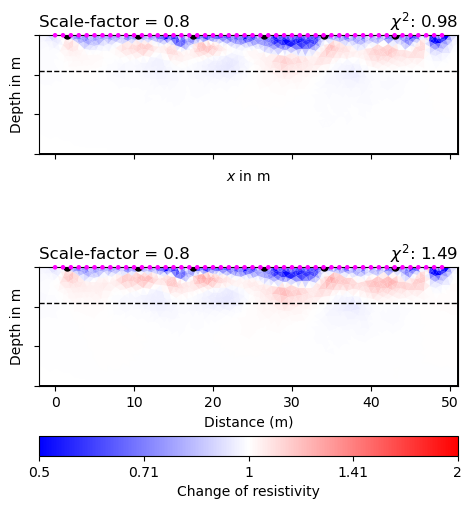

In [7]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(5,6))
plt.subplots_adjust(hspace=-0.5)
for nr, chi2, m, name in zip([0,1],[chi2_oT, chi2_wT], [mod, mod_Tcorr], ['withoutTcorr', 'withTcorr']):
    ratio = m[1] / m[0]
    bild2 = manager[0].showResult(model= ratio,coverage = manager[0].coverage(),
            cMin=1/2, cMax=2, cMap= 'bwr', ax= axs[nr], label = 'Change of resistivity', logScale= True)
    if nr < 1:
        cb = bild2[-1]
        cb.remove() 
        axs[nr].xaxis.set_ticklabels([])  # Unterdrückt die x-Achse Labels
    if nr == 1:
        axs[nr].set_xlabel('Distance (m)')
        
    axs[nr].yaxis.set_ticklabels([])  # Unterdrückt die y-Achse Labels
    axs[nr].set_title('$\chi^2$: '+ str(chi2[0]), loc = 'right')
    axs[nr].set_title('Scale-factor = '+ str(0.8), loc = 'left')
    # Prinzenpark
    axs[nr].plot(1.5,0, '.', markersize = '10', color = 'black')
    axs[nr].plot(10.5,0, '.', markersize = '10', color = 'black')
    axs[nr].plot(17.5,0, '.', markersize = '10', color = 'black')
    axs[nr].plot(26.5,0, '.', markersize = '10', color = 'black')
    axs[nr].plot(34,0, '.', markersize = '10 ', color = 'black')
    axs[nr].plot(43,0, '.', markersize = '10 ', color = 'black')
    axs[nr].set_ylim(-15, 0)
    axs[nr].axhline(y=-4.5, color='k', linewidth = 1,linestyle='--')

#fig.savefig('./Fig8/FTL_inversion_new.png' , bbox_inches = 'tight', dpi=300)